## Data Preprocessing

In [504]:
import os
import sys
import warnings

import numpy as np
import pandas as pd

if not sys.warnoptions:
    warnings.simplefilter("ignore")
    os.environ["PYTHONWARNINGS"] = "ignore"


### Data Wrangling and EDA


In [505]:
restaurants = pd.read_csv(
    "/Users/jw/Desktop/MIDS SP25/Machine Learning/Final Project/healthinspections_2024_withsvi.csv"
)
restaurants

,Unnamed: 0,INSPECTION_DATE,STORE_NAME,STREET_ADDRESS,CITY,ZIP5,SERVICE_DESCRIPTION,SCORE,GRADE,STREET_ADDRESS_LINE2,...,MP_ASIAN,EP_AIAN,MP_AIAN,EP_NHPI,MP_NHPI,EP_TWOMORE,MP_TWOMORE,EP_OTHERRACE,MP_OTHERRACE,ZCTA5
0,0,2024-01-02,3RD ST CHEVRON,3817 W 3RD ST,LOS ANGELES,90020,ROUTINE INSPECTION,90.0,A,NaN,...,2.0,0.1,0.1,0.1,0.1,3.4,0.8,0.5,0.3,90004.0
1,1,2024-01-02,7-ELEVEN #34473B,5905 SOUTH ST,LAKEWOOD,90713,ROUTINE INSPECTION,97.0,A,NaN,...,2.1,0.1,0.1,0.8,0.6,5.5,1.5,0.6,0.3,90713.0
2,2,2024-01-02,7-ELEVEN #39023B,4111 VENICE BLVD,LOS ANGELES,90019,ROUTINE INSPECTION,96.0,A,NaN,...,1.5,0.1,0.1,0.1,0.1,3.2,1.0,0.8,0.5,90019.0
3,3,2024-01-02,7-ELEVEN #39714,6051 HOLLYWOOD BLVD # 111,LOS ANGELES,90028,ROUTINE INSPECTION,94.0,A,NaN,...,2.5,0.9,0.5,0.0,0.1,4.5,1.0,1.8,0.8,90028.0
4,4,2024-01-02,AEIRLOOM-CATCHER,10550 RIVERSIDE DR,NORTH HOLLYWOOD,91602,ROUTINE INSPECTION,92.0,A,NaN,...,2.6,0.4,0.4,0.2,0.2,4.7,1.4,0.6,0.5,91602.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52938,52938,2024-01-02,Subway #43833,7709 E BEN WHITE BLVD EB SVRD,AUSTIN,78744.0,Routine Inspection,91.0,NaN,Unit 104,...,0.9,0.2,0.1,0.1,0.1,2.7,0.7,0.0,0.1,78741.0
52939,52939,2024-01-02,ZZa Pizza + Salad,15511 W SH 71,BEE CAVE,78738.0,Routine Inspection,92.0,NaN,UNIT 150,...,3.1,0.1,0.1,0.0,0.2,2.3,1.0,0.1,0.1,78738.0
52940,52940,2024-01-02,International Food Market,11331 N LAMAR BLVD,AUSTIN,78753.0,Routine Inspection,89.0,NaN,Unit H,...,1.9,0.0,0.1,0.0,0.1,2.6,1.3,0.3,0.3,78753.0
52941,52941,2024-01-02,Jack in the Box #912,6540 ED BLUESTEIN SB BLVD,AUSTIN,78723.0,Routine Inspection,94.0,NaN,NaN,...,1.4,0.0,0.1,0.0,0.1,3.6,1.4,0.3,0.2,78723.0


In [506]:
# subsetting to only CA
restaurants = restaurants[restaurants["STATE"] == "CA"]
restaurants

,Unnamed: 0,INSPECTION_DATE,STORE_NAME,STREET_ADDRESS,CITY,ZIP5,SERVICE_DESCRIPTION,SCORE,GRADE,STREET_ADDRESS_LINE2,...,MP_ASIAN,EP_AIAN,MP_AIAN,EP_NHPI,MP_NHPI,EP_TWOMORE,MP_TWOMORE,EP_OTHERRACE,MP_OTHERRACE,ZCTA5
0,0,2024-01-02,3RD ST CHEVRON,3817 W 3RD ST,LOS ANGELES,90020,ROUTINE INSPECTION,90.0,A,NaN,...,2.0,0.1,0.1,0.1,0.1,3.4,0.8,0.5,0.3,90004.0
1,1,2024-01-02,7-ELEVEN #34473B,5905 SOUTH ST,LAKEWOOD,90713,ROUTINE INSPECTION,97.0,A,NaN,...,2.1,0.1,0.1,0.8,0.6,5.5,1.5,0.6,0.3,90713.0
2,2,2024-01-02,7-ELEVEN #39023B,4111 VENICE BLVD,LOS ANGELES,90019,ROUTINE INSPECTION,96.0,A,NaN,...,1.5,0.1,0.1,0.1,0.1,3.2,1.0,0.8,0.5,90019.0
3,3,2024-01-02,7-ELEVEN #39714,6051 HOLLYWOOD BLVD # 111,LOS ANGELES,90028,ROUTINE INSPECTION,94.0,A,NaN,...,2.5,0.9,0.5,0.0,0.1,4.5,1.0,1.8,0.8,90028.0
4,4,2024-01-02,AEIRLOOM-CATCHER,10550 RIVERSIDE DR,NORTH HOLLYWOOD,91602,ROUTINE INSPECTION,92.0,A,NaN,...,2.6,0.4,0.4,0.2,0.2,4.7,1.4,0.6,0.5,91602.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37638,37638,2024-12-31,STANDARD STATIONS SPORTS BAR,226 STANDARD ST,EL SEGUNDO,90245.0,ROUTINE INSPECTION,73.0,C,NaN,...,1.8,0.1,0.1,0.0,0.2,8.8,2.5,0.1,0.1,90245.0
37639,37639,2024-12-31,SUBWAY,657 W REDONDO BEACH BLVD,GARDENA,90247.0,ROUTINE INSPECTION,95.0,A,NaN,...,1.9,0.1,0.1,0.0,0.1,2.8,0.9,0.7,0.4,90247.0
37640,37640,2024-12-31,SUBWAY #3675,5841 FIRESTONE BLVD,SOUTH GATE,90280.0,ROUTINE INSPECTION,91.0,A,STE #D,...,0.5,0.1,0.1,0.2,0.2,0.2,0.1,0.2,0.2,90280.0
37641,37641,2024-12-31,SUBWAY #44267,700 W IMPERIAL HWY # 107,LOS ANGELES,90044.0,ROUTINE INSPECTION,95.0,A,NaN,...,0.4,0.4,0.2,0.1,0.1,0.8,0.3,0.4,0.2,90044.0


In [507]:
restaurants = restaurants[
    [
        "INSPECTION_DATE",
        "SCORE",
        "GRADE",
        "STORE_NAME",
        "STREET_ADDRESS",
        "CITY",
        "ZIP5",
        "EP_POV150",
        "EP_UNEMP",
        "EP_HBURD",
        "EP_NOHSDP",
        "EP_UNINSUR",
        "EP_AGE65",
        "EP_AGE17",
        "EP_DISABL",
        "EP_SNGPNT",
        "EP_LIMENG",
        "EP_MINRTY",
        "EP_MUNIT",
        "EP_MOBILE",
        "EP_CROWD",
        "EP_NOVEH",
        "EP_GROUPQ",
        "F_POV150",
        "SERVICE_DESCRIPTION",
    ]
]

### Census Data Wrangling 

In [508]:
census = pd.read_csv(
    "/Users/jw/Desktop/MIDS SP25/Machine Learning/Final Project/healthinspections_2024_censusindicators.csv"
)
census

,INSPECTION_DATE,STORE_NAME,STREET_ADDRESS,CITY,ZIP5,SERVICE_DESCRIPTION,SCORE,GRADE,STREET_ADDRESS_LINE2,INSPDATE_YEAR,...,Zip,Country,Source,geometry,PRIMARY_ZCTA,buffer,AVG_INCOME_NEARBY_ZCTAS,AVG_HH_SIZE_NEARBY_ZCTAS,AVG_RENT_NEARBY_ZCTAS,AVG_POP_NEARBY_ZCTAS
0,2024-01-02,3RD ST CHEVRON,3817 W 3RD ST,LOS ANGELES,90020,ROUTINE INSPECTION,90.0,A,NaN,2024,...,90020.0,US,City of Los Angeles (CC0 1.0),POINT (-13168932.121192798 4038094.9968518936),90004.0,POLYGON ((-13165713.431192799 4038094.99685189...,64645.500000,2.320000,1755.800000,42499.700000
1,2024-01-02,7-ELEVEN #34473B,5905 SOUTH ST,LAKEWOOD,90713,ROUTINE INSPECTION,97.0,A,NaN,2024,...,90713.0,US,Los Angeles (Los Angeles County license to cop...,POINT (-13148707.930063948 4009888.0653141276),90713.0,POLYGON ((-13145489.240063949 4009888.06531412...,112001.714286,3.130000,2346.428571,37331.571429
2,2024-01-02,7-ELEVEN #39023B,4111 VENICE BLVD,LOS ANGELES,90019,ROUTINE INSPECTION,96.0,A,NaN,2024,...,90019.0,US,City of Los Angeles (CC0 1.0),POINT (-13172079.123197524 4034756.0163900163),90019.0,POLYGON ((-13168860.433197524 4034756.01639001...,67153.000000,2.385556,1848.000000,41001.888889
3,2024-01-02,7-ELEVEN #39714,6051 HOLLYWOOD BLVD # 111,LOS ANGELES,90028,ROUTINE INSPECTION,94.0,A,NaN,2024,...,90028.0,US,City of Los Angeles (CC0 1.0),POINT (-13171547.01603153 4042482.1722482773),90028.0,POLYGON ((-13168328.32603153 4042482.172248277...,79224.375000,1.988750,1992.750000,38403.625000
4,2024-01-02,AEIRLOOM-CATCHER,10550 RIVERSIDE DR,NORTH HOLLYWOOD,91602,ROUTINE INSPECTION,92.0,A,NaN,2024,...,91602.0,US,City of Los Angeles (CC0 1.0),POINT (-13175841.721986335 4049232.9093501884),91602.0,POLYGON ((-13172623.031986335 4049232.90935018...,100588.428571,1.932500,2194.714286,27773.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52938,2024-01-02,Subway #43833,7709 E BEN WHITE BLVD EB SVRD,AUSTIN,78744.0,Routine Inspection,91.0,NaN,Unit 104,2024,...,78744.0,US,TIGER/Line® dataset from the US Census Bureau,POINT (-10874630.848093474 3531741.217826435),78741.0,POLYGON ((-10871412.158093475 3531741.21782643...,70385.000000,2.586000,1384.000000,25493.800000
52939,2024-01-02,ZZa Pizza + Salad,15511 W SH 71,BEE CAVE,78738.0,Routine Inspection,92.0,NaN,UNIT 150,2024,...,78738.0,US,City of Austin (Public Domain),POINT (-10907713.10832589 3544338.9375500926),78738.0,POLYGON ((-10904494.41832589 3544338.937550092...,149513.500000,2.390000,1922.500000,25440.500000
52940,2024-01-02,International Food Market,11331 N LAMAR BLVD,AUSTIN,78753.0,Routine Inspection,89.0,NaN,Unit H,2024,...,78753.0,US,City of Austin (Public Domain),POINT (-10874225.979105456 3552771.754906076),78753.0,POLYGON ((-10871007.289105456 3552771.75490607...,74772.333333,2.320000,1566.666667,46817.000000
52941,2024-01-02,Jack in the Box #912,6540 ED BLUESTEIN SB BLVD,AUSTIN,78723.0,Routine Inspection,94.0,NaN,NaN,2024,...,78723.0,US,TIGER/Line® dataset from the US Census Bureau,POINT (-10871589.154327037 3542717.569882022),78723.0,POLYGON ((-10868370.464327037 3542717.56988202...,88392.666667,2.450000,1658.333333,23473.666667


In [509]:
# dropping columns that are not needed in census data
census = census[
    [
        "INSPECTION_DATE",
        "STORE_NAME",
        "STREET_ADDRESS",
        "CITY",
        "ZIP5",
        "AVG_INCOME_NEARBY_ZCTAS",
        "AVG_HH_SIZE_NEARBY_ZCTAS",
        "AVG_RENT_NEARBY_ZCTAS",
        "AVG_POP_NEARBY_ZCTAS",
    ]
]

In [510]:
# merging the census data with the restaurant data
# merging on inspection date as one resturant can have multiple inspections
# and we want to keep all the inspections


restaurants_merged = pd.merge(
    census,
    restaurants,
    how="left",
    on=[
        "INSPECTION_DATE",
        "STORE_NAME",
        "STREET_ADDRESS",
        "CITY",
        "ZIP5",
    ],
    indicator=True,
)
restaurants_merged

,INSPECTION_DATE,STORE_NAME,STREET_ADDRESS,CITY,ZIP5,AVG_INCOME_NEARBY_ZCTAS,AVG_HH_SIZE_NEARBY_ZCTAS,AVG_RENT_NEARBY_ZCTAS,AVG_POP_NEARBY_ZCTAS,SCORE,...,EP_LIMENG,EP_MINRTY,EP_MUNIT,EP_MOBILE,EP_CROWD,EP_NOVEH,EP_GROUPQ,F_POV150,SERVICE_DESCRIPTION,_merge
0,2024-01-02,3RD ST CHEVRON,3817 W 3RD ST,LOS ANGELES,90020,64645.500000,2.320000,1755.800000,42499.700000,90.0,...,21.3,79.4,51.8,0.2,18.5,16.9,1.6,0.0,ROUTINE INSPECTION,both
1,2024-01-02,7-ELEVEN #34473B,5905 SOUTH ST,LAKEWOOD,90713,112001.714286,3.130000,2346.428571,37331.571429,97.0,...,2.9,54.5,1.6,0.0,3.5,1.7,0.2,0.0,ROUTINE INSPECTION,both
2,2024-01-02,7-ELEVEN #39023B,4111 VENICE BLVD,LOS ANGELES,90019,67153.000000,2.385556,1848.000000,41001.888889,96.0,...,17.2,82.5,25.5,0.2,12.3,13.2,2.4,0.0,ROUTINE INSPECTION,both
3,2024-01-02,7-ELEVEN #39714,6051 HOLLYWOOD BLVD # 111,LOS ANGELES,90028,79224.375000,1.988750,1992.750000,38403.625000,94.0,...,12.9,57.7,82.9,0.0,8.1,27.4,6.0,0.0,ROUTINE INSPECTION,both
4,2024-01-02,AEIRLOOM-CATCHER,10550 RIVERSIDE DR,NORTH HOLLYWOOD,91602,100588.428571,1.932500,2194.714286,27773.000000,92.0,...,2.9,40.6,55.2,0.4,3.6,4.7,0.0,0.0,ROUTINE INSPECTION,both
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
68886,2024-01-02,Subway #43833,7709 E BEN WHITE BLVD EB SVRD,AUSTIN,78744.0,70385.000000,2.586000,1384.000000,25493.800000,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,left_only
68887,2024-01-02,ZZa Pizza + Salad,15511 W SH 71,BEE CAVE,78738.0,149513.500000,2.390000,1922.500000,25440.500000,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,left_only
68888,2024-01-02,International Food Market,11331 N LAMAR BLVD,AUSTIN,78753.0,74772.333333,2.320000,1566.666667,46817.000000,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,left_only
68889,2024-01-02,Jack in the Box #912,6540 ED BLUESTEIN SB BLVD,AUSTIN,78723.0,88392.666667,2.450000,1658.333333,23473.666667,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,left_only


In [511]:
# checking for duplicates

# merging on store name, street address, city, and zip code is not a
# 1-1 merge as strip malls, big in CA, have multiple stores with the same
# address

duplicates = restaurants_merged.duplicated(
    subset=["INSPECTION_DATE", "STORE_NAME", "STREET_ADDRESS", "CITY", "ZIP5"]
)
restaurants_merged[duplicates]

,INSPECTION_DATE,STORE_NAME,STREET_ADDRESS,CITY,ZIP5,AVG_INCOME_NEARBY_ZCTAS,AVG_HH_SIZE_NEARBY_ZCTAS,AVG_RENT_NEARBY_ZCTAS,AVG_POP_NEARBY_ZCTAS,SCORE,...,EP_LIMENG,EP_MINRTY,EP_MUNIT,EP_MOBILE,EP_CROWD,EP_NOVEH,EP_GROUPQ,F_POV150,SERVICE_DESCRIPTION,_merge
32,2024-01-02,CARDENAS MARKET #20,1645 W HOLT AVE,POMONA,91768,88993.200000,3.156000,1916.000000,44217.200000,93.0,...,15.1,87.1,15.1,7.1,17.1,6.0,13.4,0.0,ROUTINE INSPECTION,both
33,2024-01-02,CARDENAS MARKET #20,1645 W HOLT AVE,POMONA,91768,88993.200000,3.156000,1916.000000,44217.200000,93.0,...,15.1,87.1,15.1,7.1,17.1,6.0,13.4,0.0,ROUTINE INSPECTION,both
34,2024-01-02,CARDENAS MARKET #20,1645 W HOLT AVE,POMONA,91768,88993.200000,3.156000,1916.000000,44217.200000,97.0,...,15.1,87.1,15.1,7.1,17.1,6.0,13.4,0.0,ROUTINE INSPECTION,both
35,2024-01-02,CARDENAS MARKET #20,1645 W HOLT AVE,POMONA,91768,88993.200000,3.156000,1916.000000,44217.200000,99.0,...,15.1,87.1,15.1,7.1,17.1,6.0,13.4,0.0,ROUTINE INSPECTION,both
36,2024-01-02,CARDENAS MARKET #20,1645 W HOLT AVE,POMONA,91768,88993.200000,3.156000,1916.000000,44217.200000,93.0,...,15.1,87.1,15.1,7.1,17.1,6.0,13.4,0.0,ROUTINE INSPECTION,both
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
65801,2024-06-10,7-Eleven 36559H,3636 N FM 620 RD,AUSTIN,78734.0,143876.333333,2.436667,1756.333333,19259.666667,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,left_only
66560,2024-04-22,Denny's #1008,2320 S IH 35 SB SVRD,AUSTIN,78704.0,97128.000000,1.958333,1850.166667,40925.500000,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,left_only
68559,2024-01-16,PF - Casa Garcia's Mexican Restaurant,15803 WINDERMERE DR,PFLUGERVILLE,78660.0,82955.750000,2.477500,1596.000000,66483.500000,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,left_only
68563,2024-01-16,PF - Casa Garcia's Mexican Restaurant,15803 WINDERMERE DR,PFLUGERVILLE,78660.0,82955.750000,2.477500,1596.000000,66483.500000,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,left_only


In [512]:
# we will drop all observation that are missing svi data post merge
restaurants_merged = restaurants_merged[restaurants_merged["_merge"] == "both"]
restaurants_merged

,INSPECTION_DATE,STORE_NAME,STREET_ADDRESS,CITY,ZIP5,AVG_INCOME_NEARBY_ZCTAS,AVG_HH_SIZE_NEARBY_ZCTAS,AVG_RENT_NEARBY_ZCTAS,AVG_POP_NEARBY_ZCTAS,SCORE,...,EP_LIMENG,EP_MINRTY,EP_MUNIT,EP_MOBILE,EP_CROWD,EP_NOVEH,EP_GROUPQ,F_POV150,SERVICE_DESCRIPTION,_merge
0,2024-01-02,3RD ST CHEVRON,3817 W 3RD ST,LOS ANGELES,90020,64645.500000,2.320000,1755.800000,42499.700000,90.0,...,21.3,79.4,51.8,0.2,18.5,16.9,1.6,0.0,ROUTINE INSPECTION,both
1,2024-01-02,7-ELEVEN #34473B,5905 SOUTH ST,LAKEWOOD,90713,112001.714286,3.130000,2346.428571,37331.571429,97.0,...,2.9,54.5,1.6,0.0,3.5,1.7,0.2,0.0,ROUTINE INSPECTION,both
2,2024-01-02,7-ELEVEN #39023B,4111 VENICE BLVD,LOS ANGELES,90019,67153.000000,2.385556,1848.000000,41001.888889,96.0,...,17.2,82.5,25.5,0.2,12.3,13.2,2.4,0.0,ROUTINE INSPECTION,both
3,2024-01-02,7-ELEVEN #39714,6051 HOLLYWOOD BLVD # 111,LOS ANGELES,90028,79224.375000,1.988750,1992.750000,38403.625000,94.0,...,12.9,57.7,82.9,0.0,8.1,27.4,6.0,0.0,ROUTINE INSPECTION,both
4,2024-01-02,AEIRLOOM-CATCHER,10550 RIVERSIDE DR,NORTH HOLLYWOOD,91602,100588.428571,1.932500,2194.714286,27773.000000,92.0,...,2.9,40.6,55.2,0.4,3.6,4.7,0.0,0.0,ROUTINE INSPECTION,both
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
53586,2024-12-31,STANDARD STATIONS SPORTS BAR,226 STANDARD ST,EL SEGUNDO,90245.0,151582.250000,2.315000,2920.500000,26645.750000,73.0,...,0.8,42.5,18.5,0.0,1.8,2.2,0.2,0.0,ROUTINE INSPECTION,both
53587,2024-12-31,SUBWAY,657 W REDONDO BEACH BLVD,GARDENA,90247.0,77895.700000,3.254000,1728.000000,38888.100000,95.0,...,16.6,93.5,24.6,5.6,14.6,6.3,1.4,0.0,ROUTINE INSPECTION,both
53588,2024-12-31,SUBWAY #3675,5841 FIRESTONE BLVD,SOUTH GATE,90280.0,79197.166667,3.540000,1740.500000,60368.833333,91.0,...,22.7,97.4,9.3,1.5,21.9,8.1,0.1,0.0,ROUTINE INSPECTION,both
53589,2024-12-31,SUBWAY #44267,700 W IMPERIAL HWY # 107,LOS ANGELES,90044.0,66198.500000,3.300000,1553.900000,51712.500000,95.0,...,18.9,98.8,15.8,0.4,18.2,16.6,0.7,0.0,ROUTINE INSPECTION,both


In [513]:
#  we are checking for duplicates again to get an understanding of how many restaurants
# share the same address. it may be a unique charactersitic in our dataset
duplicates = restaurants_merged.duplicated(
    subset=["INSPECTION_DATE", "STORE_NAME", "STREET_ADDRESS", "CITY", "ZIP5"]
)
restaurants_merged[duplicates]

print(
    "Number of duplicates:",
    len(restaurants_merged[duplicates]),
    "\nPercentage of dataset that is duplicates: {:.2f}%".format(
        len(restaurants_merged[duplicates]) / len(restaurants_merged) * 100
    ),
)

Number of duplicates: 18213 
Percentage of dataset that is duplicates: 44.10%


### Variable Manipulation

In [514]:
# creating a dummy variable for service
restaurants_merged["SERVICE_DESCRIPTION"].value_counts()
restaurants_merged = pd.get_dummies(
    restaurants_merged,
    columns=["SERVICE_DESCRIPTION"],
    prefix="SERVICE",
    drop_first=False,
)

restaurants_merged

,INSPECTION_DATE,STORE_NAME,STREET_ADDRESS,CITY,ZIP5,AVG_INCOME_NEARBY_ZCTAS,AVG_HH_SIZE_NEARBY_ZCTAS,AVG_RENT_NEARBY_ZCTAS,AVG_POP_NEARBY_ZCTAS,SCORE,...,EP_MINRTY,EP_MUNIT,EP_MOBILE,EP_CROWD,EP_NOVEH,EP_GROUPQ,F_POV150,_merge,SERVICE_OWNER INITIATED INSPECTION,SERVICE_ROUTINE INSPECTION
0,2024-01-02,3RD ST CHEVRON,3817 W 3RD ST,LOS ANGELES,90020,64645.500000,2.320000,1755.800000,42499.700000,90.0,...,79.4,51.8,0.2,18.5,16.9,1.6,0.0,both,False,True
1,2024-01-02,7-ELEVEN #34473B,5905 SOUTH ST,LAKEWOOD,90713,112001.714286,3.130000,2346.428571,37331.571429,97.0,...,54.5,1.6,0.0,3.5,1.7,0.2,0.0,both,False,True
2,2024-01-02,7-ELEVEN #39023B,4111 VENICE BLVD,LOS ANGELES,90019,67153.000000,2.385556,1848.000000,41001.888889,96.0,...,82.5,25.5,0.2,12.3,13.2,2.4,0.0,both,False,True
3,2024-01-02,7-ELEVEN #39714,6051 HOLLYWOOD BLVD # 111,LOS ANGELES,90028,79224.375000,1.988750,1992.750000,38403.625000,94.0,...,57.7,82.9,0.0,8.1,27.4,6.0,0.0,both,False,True
4,2024-01-02,AEIRLOOM-CATCHER,10550 RIVERSIDE DR,NORTH HOLLYWOOD,91602,100588.428571,1.932500,2194.714286,27773.000000,92.0,...,40.6,55.2,0.4,3.6,4.7,0.0,0.0,both,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
53586,2024-12-31,STANDARD STATIONS SPORTS BAR,226 STANDARD ST,EL SEGUNDO,90245.0,151582.250000,2.315000,2920.500000,26645.750000,73.0,...,42.5,18.5,0.0,1.8,2.2,0.2,0.0,both,False,True
53587,2024-12-31,SUBWAY,657 W REDONDO BEACH BLVD,GARDENA,90247.0,77895.700000,3.254000,1728.000000,38888.100000,95.0,...,93.5,24.6,5.6,14.6,6.3,1.4,0.0,both,False,True
53588,2024-12-31,SUBWAY #3675,5841 FIRESTONE BLVD,SOUTH GATE,90280.0,79197.166667,3.540000,1740.500000,60368.833333,91.0,...,97.4,9.3,1.5,21.9,8.1,0.1,0.0,both,False,True
53589,2024-12-31,SUBWAY #44267,700 W IMPERIAL HWY # 107,LOS ANGELES,90044.0,66198.500000,3.300000,1553.900000,51712.500000,95.0,...,98.8,15.8,0.4,18.2,16.6,0.7,0.0,both,False,True


In [515]:
# encoding datetime information and dropping the original column
restaurants_merged["INSPECTION_DATE"] = restaurants_merged["INSPECTION_DATE"].astype(
    "datetime64[ns]"
)
restaurants_merged["INSPDATE_MONTH"] = restaurants_merged["INSPECTION_DATE"].dt.month
restaurants_merged["INSPDATE_DAY"] = restaurants_merged["INSPECTION_DATE"].dt.day
restaurants_merged = restaurants_merged.drop(["INSPECTION_DATE"], axis=1)
restaurants_merged

,STORE_NAME,STREET_ADDRESS,CITY,ZIP5,AVG_INCOME_NEARBY_ZCTAS,AVG_HH_SIZE_NEARBY_ZCTAS,AVG_RENT_NEARBY_ZCTAS,AVG_POP_NEARBY_ZCTAS,SCORE,GRADE,...,EP_MOBILE,EP_CROWD,EP_NOVEH,EP_GROUPQ,F_POV150,_merge,SERVICE_OWNER INITIATED INSPECTION,SERVICE_ROUTINE INSPECTION,INSPDATE_MONTH,INSPDATE_DAY
0,3RD ST CHEVRON,3817 W 3RD ST,LOS ANGELES,90020,64645.500000,2.320000,1755.800000,42499.700000,90.0,A,...,0.2,18.5,16.9,1.6,0.0,both,False,True,1,2
1,7-ELEVEN #34473B,5905 SOUTH ST,LAKEWOOD,90713,112001.714286,3.130000,2346.428571,37331.571429,97.0,A,...,0.0,3.5,1.7,0.2,0.0,both,False,True,1,2
2,7-ELEVEN #39023B,4111 VENICE BLVD,LOS ANGELES,90019,67153.000000,2.385556,1848.000000,41001.888889,96.0,A,...,0.2,12.3,13.2,2.4,0.0,both,False,True,1,2
3,7-ELEVEN #39714,6051 HOLLYWOOD BLVD # 111,LOS ANGELES,90028,79224.375000,1.988750,1992.750000,38403.625000,94.0,A,...,0.0,8.1,27.4,6.0,0.0,both,False,True,1,2
4,AEIRLOOM-CATCHER,10550 RIVERSIDE DR,NORTH HOLLYWOOD,91602,100588.428571,1.932500,2194.714286,27773.000000,92.0,A,...,0.4,3.6,4.7,0.0,0.0,both,False,True,1,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
53586,STANDARD STATIONS SPORTS BAR,226 STANDARD ST,EL SEGUNDO,90245.0,151582.250000,2.315000,2920.500000,26645.750000,73.0,C,...,0.0,1.8,2.2,0.2,0.0,both,False,True,12,31
53587,SUBWAY,657 W REDONDO BEACH BLVD,GARDENA,90247.0,77895.700000,3.254000,1728.000000,38888.100000,95.0,A,...,5.6,14.6,6.3,1.4,0.0,both,False,True,12,31
53588,SUBWAY #3675,5841 FIRESTONE BLVD,SOUTH GATE,90280.0,79197.166667,3.540000,1740.500000,60368.833333,91.0,A,...,1.5,21.9,8.1,0.1,0.0,both,False,True,12,31
53589,SUBWAY #44267,700 W IMPERIAL HWY # 107,LOS ANGELES,90044.0,66198.500000,3.300000,1553.900000,51712.500000,95.0,A,...,0.4,18.2,16.6,0.7,0.0,both,False,True,12,31


### Data Cleaning and Variable Deletion 

In [516]:
# dropping rows with NAN values
restaurants_merged = restaurants_merged.dropna()

# returning any rows with NAN values
assert (
    len(restaurants_merged[restaurants_merged.isna().any(axis=1)]) == 0
), "There are still rows with NAN values in the dataset"

In [517]:
# dropping any rows where a variable has -999 in it
restaurants_merged = restaurants_merged[(restaurants_merged != -999).all(axis=1)]

# dropping the _merge column
restaurants_merged = restaurants_merged.drop(columns=["_merge"])
restaurants_merged

# dropping the columns that are not needed
restaurants_merged = restaurants_merged.drop(
    columns=[
        "STORE_NAME",
        "STREET_ADDRESS",
        "CITY",
        "ZIP5",
    ]
)

### Removing subset of test data for our experiment 

In [518]:
# filter rows where the condition is true
condition = restaurants_merged["F_POV150"] == 1
filtered_df = restaurants_merged[condition]

# sample 20% of those rows
test_experiement3 = filtered_df.sample(frac=0.2, random_state=42)

# drop those sampled rows from the original DataFrame
restaurants_cleaned = restaurants_merged.drop(test_experiement3.index)

# dropping F_POV150 since it would be likely collinear with the other variables
restaurants_cleaned = restaurants_cleaned.drop(columns=["F_POV150"])

restaurants_cleaned

,AVG_INCOME_NEARBY_ZCTAS,AVG_HH_SIZE_NEARBY_ZCTAS,AVG_RENT_NEARBY_ZCTAS,AVG_POP_NEARBY_ZCTAS,SCORE,GRADE,EP_POV150,EP_UNEMP,EP_HBURD,EP_NOHSDP,...,EP_MINRTY,EP_MUNIT,EP_MOBILE,EP_CROWD,EP_NOVEH,EP_GROUPQ,SERVICE_OWNER INITIATED INSPECTION,SERVICE_ROUTINE INSPECTION,INSPDATE_MONTH,INSPDATE_DAY
0,64645.500000,2.320000,1755.800000,42499.700000,90.0,A,31.9,7.4,48.8,22.9,...,79.4,51.8,0.2,18.5,16.9,1.6,False,True,1,2
1,112001.714286,3.130000,2346.428571,37331.571429,97.0,A,7.9,5.6,16.5,8.0,...,54.5,1.6,0.0,3.5,1.7,0.2,False,True,1,2
2,67153.000000,2.385556,1848.000000,41001.888889,96.0,A,28.0,8.5,41.3,21.6,...,82.5,25.5,0.2,12.3,13.2,2.4,False,True,1,2
3,79224.375000,1.988750,1992.750000,38403.625000,94.0,A,31.3,10.3,46.8,10.1,...,57.7,82.9,0.0,8.1,27.4,6.0,False,True,1,2
4,100588.428571,1.932500,2194.714286,27773.000000,92.0,A,13.3,7.8,34.3,4.8,...,40.6,55.2,0.4,3.6,4.7,0.0,False,True,1,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
53586,151582.250000,2.315000,2920.500000,26645.750000,73.0,C,6.9,5.4,17.6,1.7,...,42.5,18.5,0.0,1.8,2.2,0.2,False,True,12,31
53587,77895.700000,3.254000,1728.000000,38888.100000,95.0,A,21.4,4.9,36.7,22.4,...,93.5,24.6,5.6,14.6,6.3,1.4,False,True,12,31
53588,79197.166667,3.540000,1740.500000,60368.833333,91.0,A,25.3,7.8,38.9,41.1,...,97.4,9.3,1.5,21.9,8.1,0.1,False,True,12,31
53589,66198.500000,3.300000,1553.900000,51712.500000,95.0,A,40.2,10.3,51.5,36.2,...,98.8,15.8,0.4,18.2,16.6,0.7,False,True,12,31


### Plot the distribution for all variables

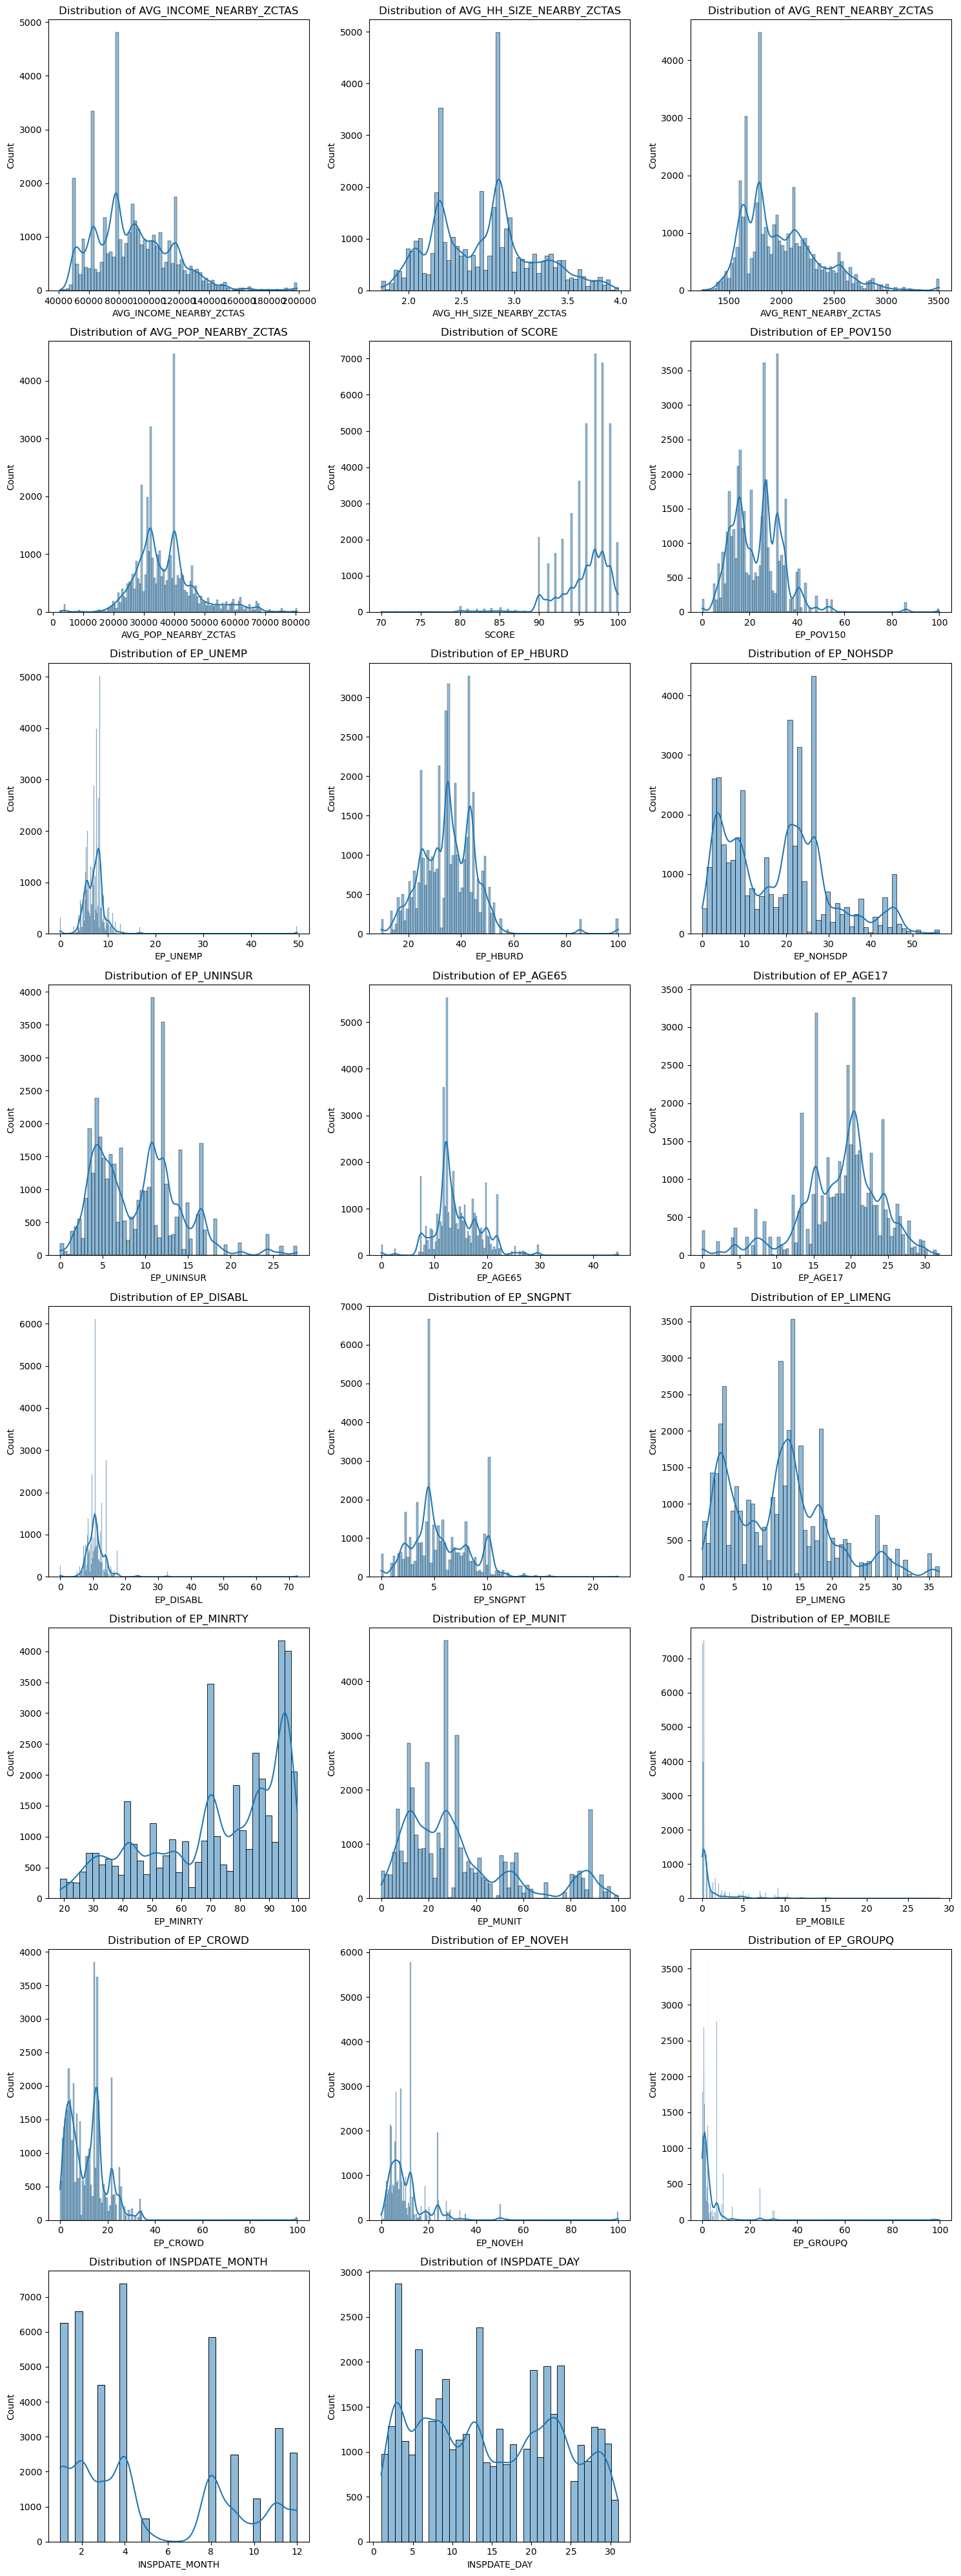

In [519]:
# Plot the distribution for all variables in a grid
import matplotlib.pyplot as plt
import seaborn as sns

# Select only numeric columns
numeric_cols = restaurants_cleaned.select_dtypes(include="number").columns

# Set up the grid size
num_plots = len(numeric_cols)
cols = 3
rows = (num_plots // cols) + (num_plots % cols > 0)

plt.figure(figsize=(15, 5 * rows))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(rows, cols, i)
    sns.histplot(restaurants_cleaned[col], kde=True)
    plt.title(f"Distribution of {col}")

plt.tight_layout()
plt.show()

In [520]:
restaurants_cleaned[numeric_cols].skew().sort_values(ascending=False)

EP_GROUPQ                   9.702198
EP_UNEMP                    8.784595
EP_DISABL                   8.492686
EP_NOVEH                    4.349269
EP_MOBILE                   3.521188
EP_CROWD                    1.909401
EP_POV150                   1.262473
EP_HBURD                    1.224303
EP_MUNIT                    1.148993
AVG_RENT_NEARBY_ZCTAS       0.985260
EP_AGE65                    0.908184
AVG_POP_NEARBY_ZCTAS        0.847033
AVG_INCOME_NEARBY_ZCTAS     0.732191
EP_UNINSUR                  0.649407
EP_LIMENG                   0.633971
EP_SNGPNT                   0.563606
EP_NOHSDP                   0.529121
INSPDATE_MONTH              0.511671
AVG_HH_SIZE_NEARBY_ZCTAS    0.312845
INSPDATE_DAY                0.109783
EP_MINRTY                  -0.612979
EP_AGE17                   -0.743234
SCORE                      -2.077505
dtype: float64

In [521]:
# log transform the skewed variables
# List of skewed variables you want to transform
log_vars = [
    "EP_GROUPQ",
    "EP_UNEMP",
    "EP_DISABL",
    "EP_NOVEH",
    "EP_MOBILE",
    "EP_CROWD",
    "EP_POV150",
    "EP_HBURD",
    "EP_MUNIT",
]

# Apply log1p to each (handles zeros safely)
for var in log_vars:
    restaurants_cleaned[f"LOG_{var}"] = np.log1p(restaurants_cleaned[var])

### Subsetting for two training datasets (scores and grades)

Ask team about whether we want to include the adjunct race variables on the last page.

In [522]:
# creating training dataset from subset of restaurants dataset (using scores)
CA_restaurant_model_scores = restaurants_cleaned.drop(columns=["GRADE"])
CA_restaurant_model_scores

,AVG_INCOME_NEARBY_ZCTAS,AVG_HH_SIZE_NEARBY_ZCTAS,AVG_RENT_NEARBY_ZCTAS,AVG_POP_NEARBY_ZCTAS,SCORE,EP_POV150,EP_UNEMP,EP_HBURD,EP_NOHSDP,EP_UNINSUR,...,INSPDATE_DAY,LOG_EP_GROUPQ,LOG_EP_UNEMP,LOG_EP_DISABL,LOG_EP_NOVEH,LOG_EP_MOBILE,LOG_EP_CROWD,LOG_EP_POV150,LOG_EP_HBURD,LOG_EP_MUNIT
0,64645.500000,2.320000,1755.800000,42499.700000,90.0,31.9,7.4,48.8,22.9,15.5,...,2,0.955511,2.128232,2.251292,2.884801,0.182322,2.970414,3.493473,3.908015,3.966511
1,112001.714286,3.130000,2346.428571,37331.571429,97.0,7.9,5.6,16.5,8.0,3.0,...,2,0.182322,1.887070,2.341806,0.993252,0.000000,1.504077,2.186051,2.862201,0.955511
2,67153.000000,2.385556,1848.000000,41001.888889,96.0,28.0,8.5,41.3,21.6,15.0,...,2,1.223775,2.251292,2.341806,2.653242,0.182322,2.587764,3.367296,3.744787,3.277145
3,79224.375000,1.988750,1992.750000,38403.625000,94.0,31.3,10.3,46.8,10.1,12.6,...,2,1.945910,2.424803,2.701361,3.346389,0.000000,2.208274,3.475067,3.867026,4.429626
4,100588.428571,1.932500,2194.714286,27773.000000,92.0,13.3,7.8,34.3,4.8,5.6,...,2,0.000000,2.174752,2.174752,1.740466,0.336472,1.526056,2.660260,3.563883,4.028917
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
53586,151582.250000,2.315000,2920.500000,26645.750000,73.0,6.9,5.4,17.6,1.7,1.9,...,31,0.182322,1.856298,2.174752,1.163151,0.000000,1.029619,2.066863,2.923162,2.970414
53587,77895.700000,3.254000,1728.000000,38888.100000,95.0,21.4,4.9,36.7,22.4,11.0,...,31,0.875469,1.774952,2.517696,1.987874,1.887070,2.747271,3.109061,3.629660,3.242592
53588,79197.166667,3.540000,1740.500000,60368.833333,91.0,25.3,7.8,38.9,41.1,13.7,...,31,0.095310,2.174752,2.282382,2.208274,0.916291,3.131137,3.269569,3.686376,2.332144
53589,66198.500000,3.300000,1553.900000,51712.500000,95.0,40.2,10.3,51.5,36.2,13.7,...,31,0.530628,2.424803,2.624669,2.867899,0.336472,2.954910,3.718438,3.960813,2.821379


In [523]:
# creating training dataset from subset of restaurants dataset (using grades)
CA_restaurant_model_grades = restaurants_cleaned = restaurants_cleaned.drop(
    columns=["SCORE"]
)
CA_restaurant_model_grades

,AVG_INCOME_NEARBY_ZCTAS,AVG_HH_SIZE_NEARBY_ZCTAS,AVG_RENT_NEARBY_ZCTAS,AVG_POP_NEARBY_ZCTAS,GRADE,EP_POV150,EP_UNEMP,EP_HBURD,EP_NOHSDP,EP_UNINSUR,...,INSPDATE_DAY,LOG_EP_GROUPQ,LOG_EP_UNEMP,LOG_EP_DISABL,LOG_EP_NOVEH,LOG_EP_MOBILE,LOG_EP_CROWD,LOG_EP_POV150,LOG_EP_HBURD,LOG_EP_MUNIT
0,64645.500000,2.320000,1755.800000,42499.700000,A,31.9,7.4,48.8,22.9,15.5,...,2,0.955511,2.128232,2.251292,2.884801,0.182322,2.970414,3.493473,3.908015,3.966511
1,112001.714286,3.130000,2346.428571,37331.571429,A,7.9,5.6,16.5,8.0,3.0,...,2,0.182322,1.887070,2.341806,0.993252,0.000000,1.504077,2.186051,2.862201,0.955511
2,67153.000000,2.385556,1848.000000,41001.888889,A,28.0,8.5,41.3,21.6,15.0,...,2,1.223775,2.251292,2.341806,2.653242,0.182322,2.587764,3.367296,3.744787,3.277145
3,79224.375000,1.988750,1992.750000,38403.625000,A,31.3,10.3,46.8,10.1,12.6,...,2,1.945910,2.424803,2.701361,3.346389,0.000000,2.208274,3.475067,3.867026,4.429626
4,100588.428571,1.932500,2194.714286,27773.000000,A,13.3,7.8,34.3,4.8,5.6,...,2,0.000000,2.174752,2.174752,1.740466,0.336472,1.526056,2.660260,3.563883,4.028917
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
53586,151582.250000,2.315000,2920.500000,26645.750000,C,6.9,5.4,17.6,1.7,1.9,...,31,0.182322,1.856298,2.174752,1.163151,0.000000,1.029619,2.066863,2.923162,2.970414
53587,77895.700000,3.254000,1728.000000,38888.100000,A,21.4,4.9,36.7,22.4,11.0,...,31,0.875469,1.774952,2.517696,1.987874,1.887070,2.747271,3.109061,3.629660,3.242592
53588,79197.166667,3.540000,1740.500000,60368.833333,A,25.3,7.8,38.9,41.1,13.7,...,31,0.095310,2.174752,2.282382,2.208274,0.916291,3.131137,3.269569,3.686376,2.332144
53589,66198.500000,3.300000,1553.900000,51712.500000,A,40.2,10.3,51.5,36.2,13.7,...,31,0.530628,2.424803,2.624669,2.867899,0.336472,2.954910,3.718438,3.960813,2.821379


## Train/test split for SCORE and GRADE dataset

## Model 1: Linear Regression (using SCORE as our target)

In [524]:
# for the SCORE dataset (regression models)
from sklearn.model_selection import train_test_split

X_score = CA_restaurant_model_scores[
    [i for i in list(CA_restaurant_model_scores.columns) if i != "SCORE"]
]
y_score = CA_restaurant_model_scores[["SCORE"]]

# splitting into train, validation, test (70/15/15)
X_train_score, X_test_score, y_train_score, y_test_score = train_test_split(
    X_score, y_score, test_size=0.3, random_state=42
)

In [525]:
from sklearn.preprocessing import StandardScaler

# Initialize scaler
scaler = StandardScaler()

# Fit on training data, transform both train and test
X_train_scaled = scaler.fit_transform(X_train_score)
X_test_scaled = scaler.transform(X_test_score)

In [526]:
# standard scaling? probably not feature selection...
from sklearn.preprocessing import StandardScaler

In [527]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    auc,
    average_precision_score,
    mean_squared_error,
    precision_recall_curve,
    r2_score,
    roc_curve,
)

# regression model
linear_model = LinearRegression().fit(X_train_scaled, y_train_score)

In [528]:
# predicting target for the test set
y_pred_lin = linear_model.predict(X_test_scaled)

In [529]:
# MSE = measures the average of the squares of the errors/deviation
print("Mean Squared Error:", mean_squared_error(y_test_score, y_pred_lin))
# r2 = proportion of the variance for a dependent variable that is explained by the IVs
print("R-squared:", r2_score(y_test_score, y_pred_lin))

Mean Squared Error: 11.003838258374422
R-squared: 0.06926468831118981


> The MSE is not close to zero, and is rather high. Furthermore, a low R-squared value coupled with a high MSE also suggests that the model fails to capture the underlying patterns and makes more inaccurate predictions.

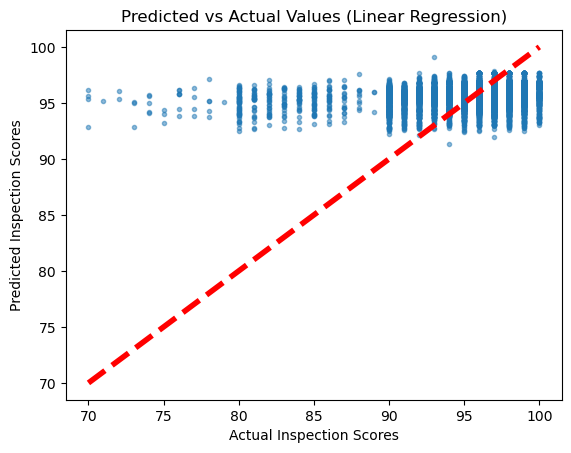

In [530]:
import matplotlib.pyplot as plt

# Plotting predicted vs. actual values
plt.scatter(y_test_score, y_pred_lin, marker=".", alpha=0.5)
plt.xlabel("Actual Inspection Scores")
plt.ylabel("Predicted Inspection Scores")
plt.title("Predicted vs Actual Values (Linear Regression)")
plt.plot(
    [y_test_score.min(), y_test_score.max()],
    [y_test_score.min(), y_test_score.max()],
    "r--",
    lw=4,
)
plt.show()

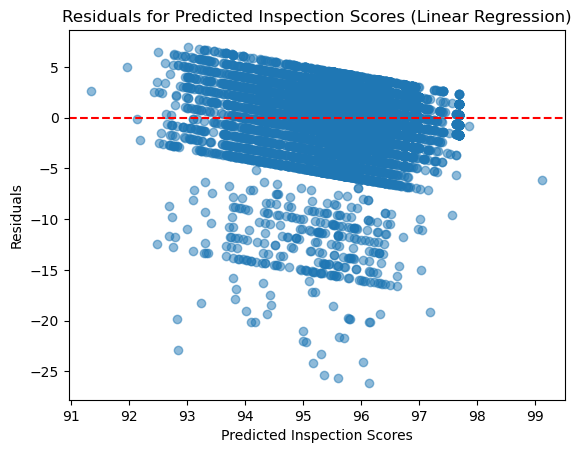

In [531]:
# Plotting residuals (difference between predicted and observed values)
residuals = y_test_score - y_pred_lin
plt.scatter(y_pred_lin, residuals, alpha=0.5)
plt.xlabel("Predicted Inspection Scores")
plt.ylabel("Residuals")
plt.title("Residuals for Predicted Inspection Scores (Linear Regression)")
plt.axhline(y=0, color="red", linestyle="--")
plt.show()

#

## Model 2: Multinomial Logistic Regression (using GRADE as our target)

In [532]:
# for the GRADE dataset (multinomial logistic regression)
from sklearn.preprocessing import (
    LabelEncoder,
    MinMaxScaler,
    StandardScaler,
    label_binarize,
)

# X = restaurant_model_grades[[i for i in list(restaurant_model_grades.columns) if i != "GRADE"]]
X = CA_restaurant_model_grades.drop("GRADE", axis=1)
y = CA_restaurant_model_grades[["GRADE"]]

# encoding target labels (A, B, C -> 0, 1, 2)
target_label = LabelEncoder()
y_encoded = target_label.fit_transform(y)
# binarize labels/one-hot encoding (needed for one-vs-rest when calculating ROC/AUC and PR curve)
y_bin = label_binarize(y_encoded, classes=[0, 1, 2])
# num_classes = len(pd.unique(y["GRADE"]))
num_classes = y_bin.shape[1]

# train/test split
X_train_grade, X_test_grade, y_train_grade, y_test_grade = train_test_split(
    X, y_bin, test_size=0.3, random_state=42
)

# normalizing our data using our MinMaxScaler
# transforms each value in the col proportionally within [0,1]
scaler = MinMaxScaler()
X_train_grade_scaled = scaler.fit_transform(X_train_grade)
X_test_grade_scaled = scaler.fit_transform(X_test_grade)
# scaler = StandardScaler()

In [533]:
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier

# ABOUT THE LOGISTIC REGRESSION MODEL:
# creating multinomial logistic regression model
# testing other solvers, but apparently, 'lbfgs' is "great for multinomial"
# liblinear only handles binary classification, so we'll test for that later
# doing l2 penalty b/c only liblinear is compatible with l1 and l2

# ABOUT THE OneVsRestClassifier:
# Fits one classifier, LR in this case, per class, used in multiclass logistic regression
# will help us calculate ROC/AUC score and PR for each class relative to the others
# this is why we binarized the labels (e.g. for class A, the negative class is class B and C)
# aka we are translating multinomial log reg = multiple binary classification tasks, one per class
LR = OneVsRestClassifier(
    LogisticRegression(
        max_iter=1000,
        multi_class="multinomial",
        penalty="l2",
        solver="lbfgs",
        class_weight="balanced",
    )
)

In [534]:
# predicting confidence scores
LR_y_pred = LR.fit(X_train_grade_scaled, y_train_grade).predict_proba(
    X_test_grade_scaled
)

> For multiclass classification, it seems we calculate our ROC/AUC and PR curves differently than the straightforward binary classification models we're used to seeing in class. We essentially turn our question into multiple binary classifications. For example, below, you will see the ROC curve and PR curve for each class. In the multinomial logistic regression below, the blue line (Class 0) models the ROC curve where Class 0 (or an "A" inspection score) is the positive class and Class 1 and 2 ("B" and "C" scores) are the negative class. The orange line represents the ROC curve where Class 1 (or a grade of "B") is the positive class, and Class 0 and 2 ("A" and "C" are the negative class). And so on...

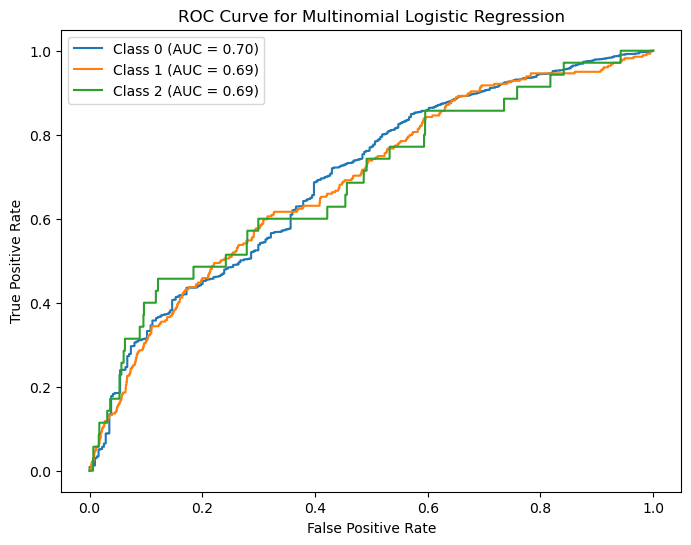

In [535]:
# the way we plotted AUC/PR curves in class is not
# supported for multiclass...doing it another way

# plotting ROC for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

# compute ROC curve and ROC area for each class
for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_grade[:, i], LR_y_pred[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(8, 6))
# plot ROC curve for a specific class
for i in range(num_classes):
    plt.plot(fpr[i], tpr[i], label=f"Class {i} (AUC = {roc_auc[i]:.2f})")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Multinomial Logistic Regression")
plt.legend()
plt.show()

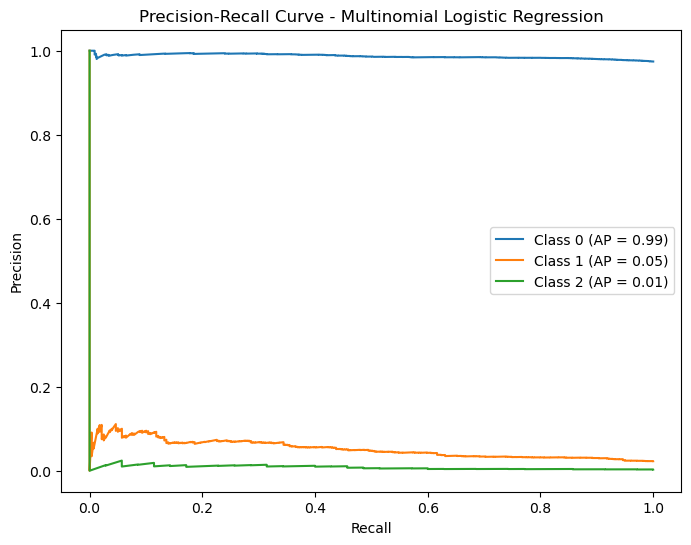

In [536]:
# plotting our PR curves for each class
precision = dict()
recall = dict()
avg_precision = dict()

# plotting each PR curve
plt.figure(figsize=(8, 6))
for i in range(num_classes):
    precision[i], recall[i], _ = precision_recall_curve(
        y_test_grade[:, i], LR_y_pred[:, i]
    )
    avg_precision[i] = average_precision_score(y_test_grade[:, i], LR_y_pred[:, i])
    plt.plot(recall[i], precision[i], label=f"Class {i} (AP = {avg_precision[i]:.2f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Multinomial Logistic Regression")
plt.legend()
plt.show()

In [537]:
# predicting class labels (another way of looking at multinomial logistic regression)
# using predict instead of predict_proba
# LR_y_pred = LR.predict(X_test_grade_scaled)

In [538]:
# from sklearn.metrics import (
#    ConfusionMatrixDisplay,
#    classification_report,
#    confusion_matrix,
# )

# plotting confusion matrix for multilabel classification
# conf = confusion_matrix(y_test_grade, LR_y_pred)

# plotting with class labels (using target_label to decode back to A, B, C)
# conf_display = ConfusionMatrixDisplay(
#    confusion_matrix=conf, display_labels=target_label.classes_
# )
# conf_display.plot(cmap="Blues")
# plt.title("Confusion Matrix for Multinomial Logistic Regression (Test)")

#

## Model 3: Random Forest Classifier (using GRADE as our target)

In [540]:
from sklearn.ensemble import RandomForestClassifier

RF_classifier = OneVsRestClassifier(
    RandomForestClassifier(n_estimators=100, class_weight="balanced", random_state=42),
).fit(X_train_grade_scaled, y_train_grade)

In [541]:
RF_cls_y_pred = RF_classifier.predict_proba(X_test_grade_scaled)

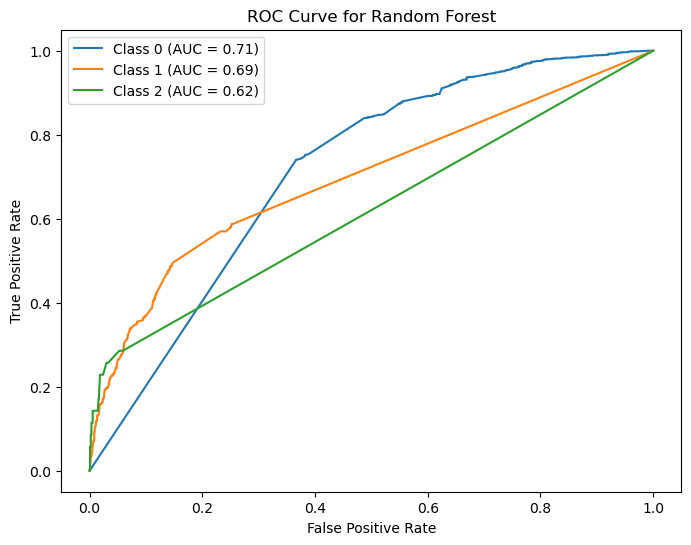

In [542]:
# Calculating ROC curve
fpr = dict()
tpr = dict()
roc_auc = dict()

# compute ROC curve and ROC area for each class
for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_grade[:, i], RF_cls_y_pred[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(8, 6))
# plot ROC curve for a specific class
for i in range(num_classes):
    plt.plot(fpr[i], tpr[i], label=f"Class {i} (AUC = {roc_auc[i]:.2f})")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Random Forest")
plt.legend()
plt.show()

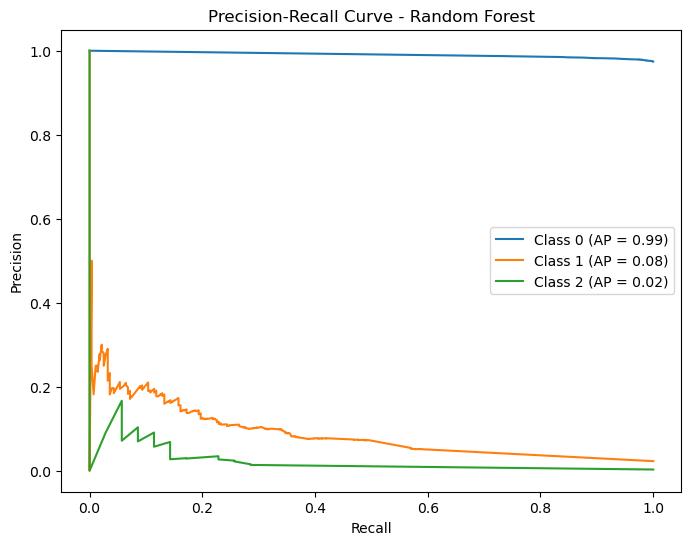

In [543]:
# plotting our PR curves for each class
precision = dict()
recall = dict()
avg_precision = dict()

# plotting each PR curve
plt.figure(figsize=(8, 6))
for i in range(num_classes):
    precision[i], recall[i], _ = precision_recall_curve(
        y_test_grade[:, i], RF_cls_y_pred[:, i]
    )
    avg_precision[i] = average_precision_score(y_test_grade[:, i], RF_cls_y_pred[:, i])
    plt.plot(recall[i], precision[i], label=f"Class {i} (AP = {avg_precision[i]:.2f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Random Forest")
plt.legend()
plt.show()

#

## Model 5: XGBoost (using GRADE as our target)

In [545]:
from xgboost import XGBClassifier

# multi:softprob > tells XGBoost to perform multi-class classification and outputs class probabilities (not just labels)
# note: we would do softmax for class labels
# eval_metric = mlogloss > common choice for multi-class classification tasks
xgb = XGBClassifier(
    objective="multi:softprob",
    num_class=3,
    eval_metric="mlogloss",
    use_label_encoder=False,
    class_weight="balanced",
)

In [546]:
# because we used label_binarize to one hot encode our Y to calculate ROC/AUC and PR,
# we need to pass single-label form, which is what XGBoost expects

# converting one-hot encoded target to class labels
y_train_single = np.argmax(y_train_grade, axis=1)

xgb.fit(X_train_grade_scaled, y_train_single)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              class_weight='balanced', colsample_bylevel=None,
              colsample_bynode=None, colsample_bytree=None, device=None,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric='mlogloss', feature_types=None, feature_weights=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None, ...)

In [547]:
# predicting probabilities
XGB_y_pred = xgb.predict_proba(X_test_grade)

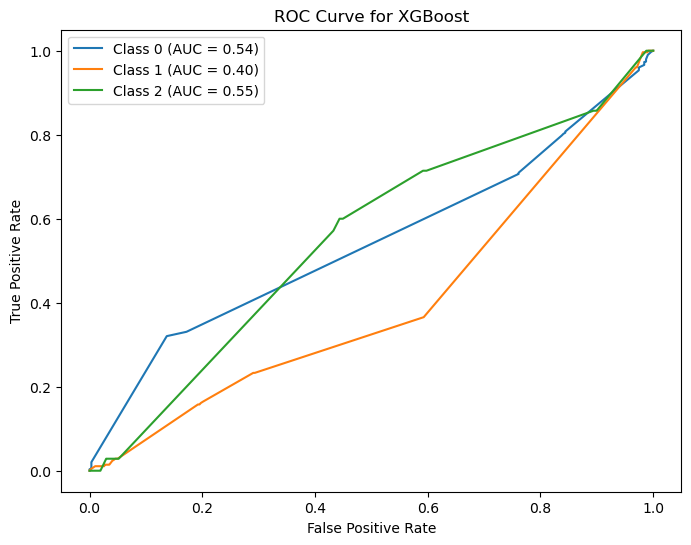

In [548]:
# Calculating ROC curve
fpr = dict()
tpr = dict()
roc_auc = dict()

# compute ROC curve and ROC area for each class
for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_grade[:, i], XGB_y_pred[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(8, 6))
# plot ROC curve for a specific class
for i in range(num_classes):
    plt.plot(fpr[i], tpr[i], label=f"Class {i} (AUC = {roc_auc[i]:.2f})")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for XGBoost")
plt.legend()
plt.show()

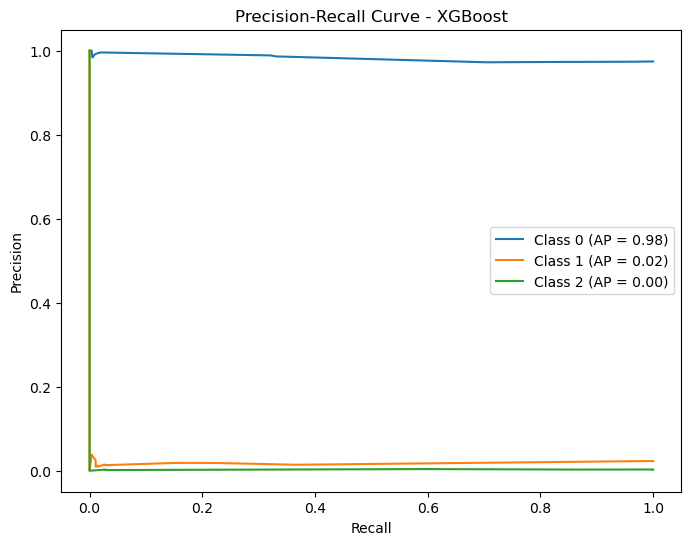

In [549]:
# plotting our PR curves for each class
precision = dict()
recall = dict()
avg_precision = dict()

# plotting each PR curve
plt.figure(figsize=(8, 6))
for i in range(num_classes):
    precision[i], recall[i], _ = precision_recall_curve(
        y_test_grade[:, i], XGB_y_pred[:, i]
    )
    avg_precision[i] = average_precision_score(y_test_grade[:, i], XGB_y_pred[:, i])
    plt.plot(recall[i], precision[i], label=f"Class {i} (AP = {avg_precision[i]:.2f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - XGBoost")
plt.legend()
plt.show()

Lasso Regression

In [550]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error, r2_score

# split into train (70%) and temp (30%)
X = CA_restaurant_model_scores.drop(columns=["SCORE"])
y = CA_restaurant_model_scores["SCORE"]

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# split temp into validation (15%) and test (15%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

# create pipeline with StandardScaler + Lasso
lasso = make_pipeline(StandardScaler(), Lasso(alpha=0.01, random_state=42))

# train on training set
lasso.fit(X_train, y_train)

# validate on validation set
y_val_pred = lasso.predict(X_val)
val_mse = mean_squared_error(y_val, y_val_pred)
val_r2 = r2_score(y_val, y_val_pred)

print(f"Validation MSE: {val_mse:.2f}")
print(f"Validation R^2: {val_r2:.3f}")

# final evaluation on test set
y_test_pred = lasso.predict(X_test)
test_mse = mean_squared_error(y_test, y_test_pred)
test_r2 = r2_score(y_test, y_test_pred)

print(f"Test MSE: {test_mse:.2f}")
print(f"Test R^2: {test_r2:.3f}")

Validation MSE: 10.85
Validation R^2: 0.070
Test MSE: 11.16
Test R^2: 0.068


In [551]:
from sklearn.linear_model import Lasso

best_alpha = None
best_score = float("-inf")

for alpha in [0.001, 0.01, 0.1, 1, 10]:
    model = make_pipeline(StandardScaler(), Lasso(alpha=alpha, random_state=42))
    model.fit(X_train, y_train)
    score = model.score(X_val, y_val)
    if score > best_score:
        best_score = score
        best_alpha = alpha

print(f"Best alpha based on validation set: {best_alpha}")

Best alpha based on validation set: 0.01
